# ADE Sentence Classification
### NLP Course Final Project

**Task:** Binary sentence classification — does a sentence from a medical case report
describe an Adverse Drug Event (ADE)?

**Dataset:** ADE-Corpus-V2 (Gurulingappa et al., 2012)

**Models covered:**
1. Majority-class Baseline
2. TF-IDF + Naïve Bayes
3. TF-IDF + Logistic Regression
4. BiLSTM + BioWordVec + Query Attention *(Ramamoorthy & Murugan, 2018)*
5. PubMedBERT fine-tuned *(cf. Dong et al., 2024)*
6. OpenAI GPT few-shot prompting


## 1 — Setup

### 1.1 Install dependencies
*Run once per Colab session.*

In [1]:
!pip install -q datasets transformers accelerate openai tqdm gensim fasttext scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.1 MB/s eta 0:00:00


### 1.2 Imports & global seed

In [1]:
import re, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.pipeline          import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes       import MultinomialNB
from sklearn.linear_model      import LogisticRegression
from sklearn.dummy             import DummyClassifier
from sklearn.model_selection   import (GridSearchCV,
                                        train_test_split,
                                        StratifiedShuffleSplit)
from sklearn.metrics           import (classification_report, f1_score,
                                        accuracy_score, precision_score,
                                        recall_score, confusion_matrix,
                                        ConfusionMatrixDisplay)

from transformers import (AutoTokenizer,
                           AutoModelForSequenceClassification,
                           Trainer, TrainingArguments,
                           EarlyStoppingCallback)
from datasets import load_dataset
from datasets import Dataset as HFDataset

from openai  import OpenAI
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 2 — Data Loading & Quality Check

### 2.1 Load dataset

Dataset: **ADE-Corpus-V2** (Gurulingappa et al., 2012)
- 23,516 medical case report sentences annotated for drug-related adverse effects
- We use the binary classification split: label 1 = ADE sentence, 0 = non-ADE
- Downloaded from HuggingFace

In [2]:
# Load ADE-Corpus-V2 binary sentence classification split
df = pd.read_csv("data/dataset.csv")

print(f'Raw dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()


Raw dataset shape: (23516, 2)
Columns: ['text', 'label']


,text,label
0,Intravenous azithromycin-induced ototoxicity.,1
1,"Immobilization, while Paget's bone disease was...",1
2,Unaccountable severe hypercalcemia in a patien...,1
3,METHODS: We report two cases of pseudoporphyri...,1
4,METHODS: We report two cases of pseudoporphyri...,1


### 2.2 Missing values

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print(f'Rows with any NaN: {df.isnull().any(axis=1).sum()}')
assert df.isnull().sum().sum() == 0, 'Unexpected missing values!'
print('No missing values — dataset is complete.')

### 2.3 Class distribution (raw)

*Reference distribution before any cleaning.*

In [5]:
# Confirm label mapping
print('Label distribution (raw):')
print(df['label'].value_counts())
print(f'\n  0 = non-ADE sentence')
print(f'  1 = ADE sentence')


Label distribution (raw):
label
0    16695
1     6821
Name: count, dtype: int64

  0 = non-ADE sentence
  1 = ADE sentence


### 2.4 Duplicate analysis

In [9]:
n_total  = len(df)
n_dupes  = df.duplicated(subset='text').sum()
n_unique = n_total - n_dupes

print(f'Total rows:       {n_total:,}')
print(f'Duplicate texts:  {n_dupes:,}  ({n_dupes/n_total*100:.1f}%)')
print(f'Unique texts:     {n_unique:,}')

# Find sentences that appear under BOTH labels — annotation noise.
# A sentence labelled 1 in one row and 0 in another is ambiguous ground truth
# and must be handled before training (we keep ADE=1 as the clinically safer choice).
dup_labels = (df.groupby('text')['label']
                .nunique()
                .reset_index()
                .query('label > 1'))
print(f'\nSentences with conflicting labels: {len(dup_labels):,}')
if len(dup_labels):
    example = dup_labels.iloc[0]['text']
    print(f'Example: "{example[:100]}..."')
    print(df[df['text'] == example][['text','label']])

# Break down duplicates by class — if most duplicates are non-ADE,
# removing them will shift the imbalance ratio further toward 80/20
dup_mask = df.duplicated(subset='text', keep=False)
print('\nLabel distribution inside duplicate rows:')
print(df[dup_mask]['label'].value_counts())
print('(removing these changes the class ratio — verified in Section 4.3)')


### 2.5 Deduplication

Strategy: keep the ADE=1 label for sentences that appear under both classes (clinically safer). Report removed rows and new dataset size.

In [10]:
# 4.1 Drop duplicates (before any splitting)
# Keep first occurrence; conflicting labels → keep ADE=1 (clinically safer)
df_sorted = df.sort_values('label', ascending=False)   # ADE first
df_clean  = df_sorted.drop_duplicates(subset='text').reset_index(drop=True)

print(f'After deduplication: {len(df_clean):,} sentences')
print(f'Removed: {len(df) - len(df_clean):,} duplicates')
print()

# Class distribution AFTER deduplication
counts_clean = df_clean['label'].value_counts()
print('Class distribution after deduplication:')
for label, count in counts_clean.items():
    pct = count / len(df_clean) * 100
    name = 'ADE' if label == 1 else 'non-ADE'
    print(f'  {name} ({label}): {count:,}  ({pct:.1f}%)')


After deduplication: 20,896 sentences
Removed: 2,620 duplicates

Class distribution after deduplication:
  non-ADE (0): 16,625  (79.6%)
  ADE (1): 4,271  (20.4%)


## 3 — Exploratory Data Analysis

*All analyses below use the deduplicated dataset.*

### 3.1 Class distribution

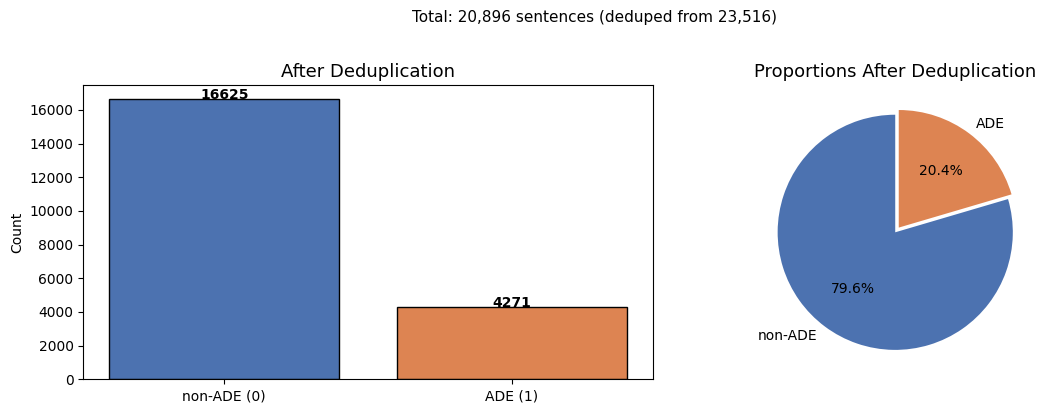

Actual imbalance after dedup: 79.6% non-ADE / 20.4% ADE
NOTE: this is ~80/20, NOT the 43/57 ratio sometimes cited for the raw corpus.


In [12]:
# 4.3 Visualise class distribution after deduplication
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts_after = df_clean['label'].value_counts()
axes[0].bar(['non-ADE (0)', 'ADE (1)'], counts_after.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('After Deduplication', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts_after.values, labels=['non-ADE', 'ADE'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Proportions After Deduplication', fontsize=13)

plt.suptitle(f'Total: {len(df_clean):,} sentences (deduped from {len(df):,})',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Correction note (this was wrong in the original notebook):
ade_pct     = counts_after[1] / len(df_clean) * 100
non_ade_pct = counts_after[0] / len(df_clean) * 100
print(f'Actual imbalance after dedup: {non_ade_pct:.1f}% non-ADE / {ade_pct:.1f}% ADE')
print('NOTE: this is ~80/20, NOT the 43/57 ratio sometimes cited for the raw corpus.')


### 3.2 Sentence length distribution

In [7]:
# Two complementary length proxies: char_len captures punctuation/spaces,
# token_len is a rougher but more linguistically meaningful measure
df['char_len']  = df['text'].str.len()
df['token_len'] = df['text'].apply(lambda t: len(t.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overlay both classes — visual overlap tells us how well length alone
# could separate ADE from non-ADE sentences (spoiler: it partially can)
for label, colour, name in [(0, '#4C72B0', 'non-ADE'), (1, '#DD8452', 'ADE')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['char_len'],  bins=50, alpha=0.6,
                 color=colour, label=name, edgecolor='none')
    axes[1].hist(subset['token_len'], bins=40, alpha=0.6,
                 color=colour, label=name, edgecolor='none')

# Global mean line — also used to justify MAX_LEN=100 in the BiLSTM (covers 99%+)
axes[0].axvline(df['char_len'].mean(),  color='red', linestyle='--',
                label=f'Mean={df["char_len"].mean():.0f}')
axes[1].axvline(df['token_len'].mean(), color='red', linestyle='--',
                label=f'Mean={df["token_len"].mean():.1f}')

axes[0].set_xlabel('Characters'); axes[0].set_title('Character Length')
axes[1].set_xlabel('Tokens');     axes[1].set_title('Token Length')
for ax in axes:
    ax.legend(); ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# min/max/percentiles: check for extreme outliers that would be hard-truncated
# at MAX_LEN=100 — if p99 < 100 we are safe; if p99 >> 100 we lose information
print(df[['char_len','token_len']].describe().round(1))


### 3.3 Discriminative vocabulary

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

# Chi-squared ranks terms by how strongly their presence predicts the class.
# Raw frequency is dominated by function words ("the", "of", "in") that appear
# identically in both classes and carry zero discriminative information.
# Chi2 surfaces the terms that genuinely separate ADE from non-ADE sentences.
vec_chi = CountVectorizer(stop_words=None, max_features=10_000, ngram_range=(1, 2))
X_chi   = vec_chi.fit_transform(df['text'])
chi2_scores, _ = chi2(X_chi, df['label'])
vocab_names    = vec_chi.get_feature_names_out()

# Per-class frequencies for the stacked bar on the right
ade_mask     = df['label'] == 1
freq_ade     = np.asarray(X_chi[ade_mask].sum(axis=0)).ravel()
freq_non_ade = np.asarray(X_chi[~ade_mask].sum(axis=0)).ravel()

# Select the 20 terms with the highest chi2 score
top_idx    = np.argsort(chi2_scores)[::-1][:20]
top_terms  = vocab_names[top_idx]
top_chi2   = chi2_scores[top_idx]
top_ade_f  = freq_ade[top_idx]
top_nonde_f= freq_non_ade[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: chi2 score — how discriminative is each term?
axes[0].barh(list(reversed(top_terms)), list(reversed(top_chi2)),
             color='#8172B2', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 20 discriminative terms (chi²)', fontsize=12)
axes[0].set_xlabel('chi² score')

# Right: where each term actually shows up — ADE or non-ADE?
y_pos = np.arange(len(top_terms))
axes[1].barh(y_pos, list(reversed(top_ade_f)),   label='ADE',     color='#DD8452', alpha=0.8)
axes[1].barh(y_pos, list(reversed(top_nonde_f)),  label='non-ADE', color='#4C72B0', alpha=0.8,
             left=list(reversed(top_ade_f)))
axes[1].set_yticks(y_pos); axes[1].set_yticklabels(list(reversed(top_terms)))
axes[1].set_title('Raw frequency split per class', fontsize=12)
axes[1].set_xlabel('Count'); axes[1].legend()

plt.tight_layout()
plt.show()


## 4 — Data Preparation

### Design decisions

| Step | Decision | Reason |
|---|---|---|
| Deduplication | **Before** split | Prevents identical sentences in train AND test — would inflate evaluation metrics |
| Lowercase | Yes | Reduces vocabulary size; medical terms are case-insensitive |
| Stopword removal | **No** | Negation markers (“not”, “without”) are clinically critical for ADE detection. Gurulingappa et al. (2012) confirmed stopword removal **hurts** classification on this corpus |
| Stemming / lemmatisation | **No** | Medical suffixes carry distinct meaning (“hepatotoxic” ≠ “hepatotoxicity”) |
| Punctuation removal | **No** | Some punctuation (dashes in drug names, parentheses for dosages) is meaningful |

### 4.1 Text normalization

In [11]:
# 4.2 Minimal text normalisation
# Only lowercase + strip — intentionally minimal (see design decisions above)

def sentence_clean(text: str) -> str:
    """Lowercase and strip whitespace. No stopwords, stemming, or punctuation removal."""
    return text.lower().strip()

df_clean['text_clean'] = df_clean['text'].apply(sentence_clean)

# Sanity check
print('Before:', df_clean['text'].iloc[0])
print('After: ', df_clean['text_clean'].iloc[0])


Before: An infant girl with choanal atresia, athelia, minor anomalies, and mild to moderate mental retardation was born to a woman treated for hyperthyroidism throughout pregnancy with methimazole and propranolol.
After:  an infant girl with choanal atresia, athelia, minor anomalies, and mild to moderate mental retardation was born to a woman treated for hyperthyroidism throughout pregnancy with methimazole and propranolol.


### 4.2 Stratified train / val / test split (70/15/15)

**Rationale:**
- Stratified: preserves the 80/20 class ratio in every split
- 70 / 15 / 15: standard split for datasets of this size
- Deduplication **before** splitting: ensures no sentence leaks between splits
- Validation set: used for early stopping and hyperparameter selection
- Test set: **never** seen during training or model selection — only for final reporting

In [13]:
X_raw = df_clean['text'].tolist()
X     = df_clean['text_clean'].tolist()   # preprocessed version
y     = df_clean['label'].to_numpy()

# Step 1: hold out test set (15%)
X_raw_tv, X_raw_test, X_tv, X_test, y_tv, y_test = train_test_split(
    X_raw, X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED)

# Step 2: split remaining into train + val
# val_size = 0.15 / 0.85 ≈ 0.176 of the tv set
X_raw_train, X_raw_val, X_train, X_val, y_train, y_val = train_test_split(
    X_raw_tv, X_tv, y_tv,
    test_size=0.15/0.85, stratify=y_tv, random_state=RANDOM_SEED)

print(f'Train: {len(X_train):,}  ({y_train.mean()*100:.1f}% ADE)')
print(f'Val:   {len(X_val):,}   ({y_val.mean()*100:.1f}% ADE)')
print(f'Test:  {len(X_test):,}   ({y_test.mean()*100:.1f}% ADE)')


Train: 14,626  (20.4% ADE)
Val:   3,135   (20.4% ADE)
Test:  3,135   (20.4% ADE)


### 4.3 Shared tokenizer

A single `shared_tokenize` function is used by **all non-transformer models**
(TF-IDF, Word2Vec, BiLSTM vocabulary) to ensure fair, consistent comparison.

Transformer models (PubMedBERT, OpenAI GPT) use their own internal subword
tokenisers and do **not** go through this function.

In [15]:
def shared_tokenize(text: str) -> list[str]:
    """
    Lowercase whitespace split.
    Used by: TF-IDF (Sections 7-8), BiLSTM vocabulary (Section 9).
    NOT used by: PubMedBERT (HuggingFace tokeniser), GPT (API).
    """
    return text.lower().split()

# Pre-tokenised strings for TF-IDF (token_pattern splits on whitespace)
X_tok_train = [' '.join(shared_tokenize(t)) for t in X_raw_train]
X_tok_val   = [' '.join(shared_tokenize(t)) for t in X_raw_val]
X_tok_test  = [' '.join(shared_tokenize(t)) for t in X_raw_test]

# Quick sanity check
print('Original:     ', X_raw_train[0])
print('Tokenised:    ', X_tok_train[0][:80], '...')
print('Token count:  ', len(shared_tokenize(X_raw_train[0])))


Original:      It was postulated that the allergic reaction was most likely caused by capecitabine or the intermediate metabolites based on the immediate reappearance of symptoms from the rechallenge, pharmacokinetic data, and well-tolerance of fluorouracil.
Tokenised:     it was postulated that the allergic reaction was most likely caused by capecitab ...
Token count:   33


### 4.4 Split summary & visualization

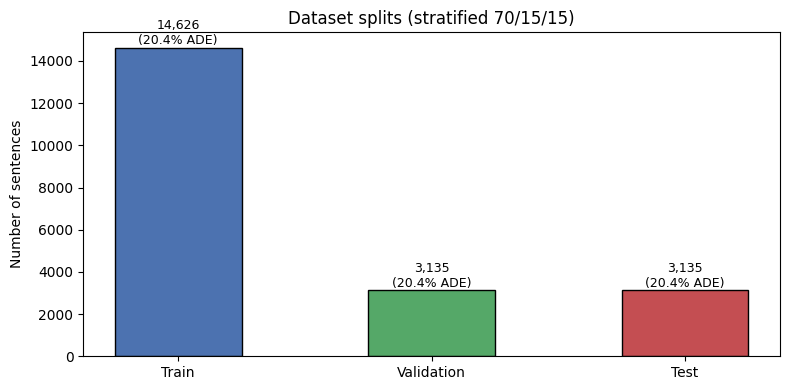

In [14]:
# Visualise split proportions
fig, ax = plt.subplots(figsize=(8, 4))
split_names  = ['Train', 'Validation', 'Test']
split_sizes  = [len(X_train), len(X_val), len(X_test)]
split_ade    = [y_train.mean(), y_val.mean(), y_test.mean()]

x = np.arange(len(split_names))
bars = ax.bar(x, split_sizes, color=['#4C72B0','#55A868','#C44E52'],
              edgecolor='black', width=0.5)
ax.set_xticks(x); ax.set_xticklabels(split_names)
ax.set_ylabel('Number of sentences')
ax.set_title('Dataset splits (stratified 70/15/15)')
for bar, size, ade_pct in zip(bars, split_sizes, split_ade):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{size:,}\n({ade_pct*100:.1f}% ADE)',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## 5 — Majority-class Baseline

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_tok_train, y_train)
y_pred_dummy = dummy.predict(X_tok_test)

print('=== Model 0: Majority-class Baseline ===')
print(classification_report(y_test, y_pred_dummy,
                             target_names=['non-ADE', 'ADE']))

cm_dummy = confusion_matrix(y_test, y_pred_dummy)
ConfusionMatrixDisplay(cm_dummy, display_labels=['non-ADE', 'ADE']).plot(cmap='Blues')
plt.title('Majority-class Baseline — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_baseline.png', dpi=150)
plt.show()

## 6 — TF-IDF + Naïve Bayes

**Reference:** Gurulingappa et al. (2012) report NB F1 = 0.14 on this corpus using
raw counts without TF-IDF weighting. Our implementation uses TF-IDF + bigrams
which substantially improves recall.

=== Model 1: TF-IDF + Naïve Bayes ===
              precision    recall  f1-score   support

     non-ADE       0.87      0.96      0.91      2494
         ADE       0.74      0.44      0.55       641

    accuracy                           0.85      3135
   macro avg       0.80      0.70      0.73      3135
weighted avg       0.84      0.85      0.84      3135



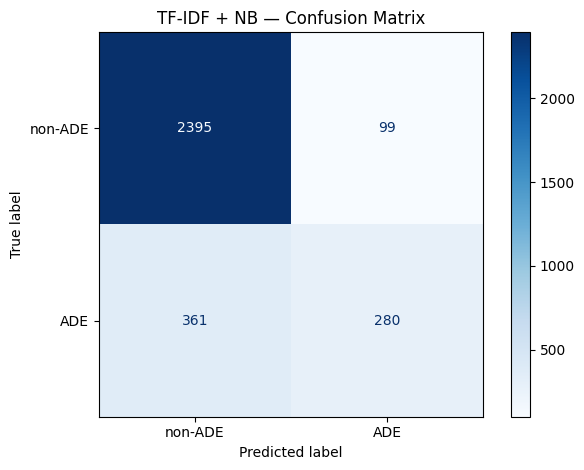

In [17]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        token_pattern=r'\S+',   # already tokenised — split on whitespace only
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
    )),
    ('clf', MultinomialNB(alpha=0.1)),
])

nb_pipeline.fit(X_tok_train, y_train)
y_pred_nb = nb_pipeline.predict(X_tok_test)

print('=== Model 1: TF-IDF + Naïve Bayes ===')
print(classification_report(y_test, y_pred_nb,
                             target_names=['non-ADE', 'ADE']))

cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=['non-ADE','ADE']).plot(cmap='Blues')
plt.title('TF-IDF + NB — Confusion Matrix')
plt.tight_layout(); plt.savefig('cm_nb.png', dpi=150); plt.show()


## 7 — TF-IDF + Logistic Regression

**Reference:** Gurulingappa et al. (2012) MaxEnt ≈ Logistic Regression.
Their result: **F1 = 0.70** (P=0.75, R=0.64) without TF-IDF weighting.

Using `Pipeline` prevents data leakage: the TF-IDF vectoriser is fit
**only on training folds**, never on validation or test data.

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'clf__C': 10.0, 'tfidf__ngram_range': (1, 2)}
Best CV F1 (ADE): 0.6509

=== Model 2: TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

     non-ADE       0.92      0.88      0.90      2494
         ADE       0.60      0.70      0.65       641

    accuracy                           0.84      3135
   macro avg       0.76      0.79      0.77      3135
weighted avg       0.85      0.84      0.85      3135



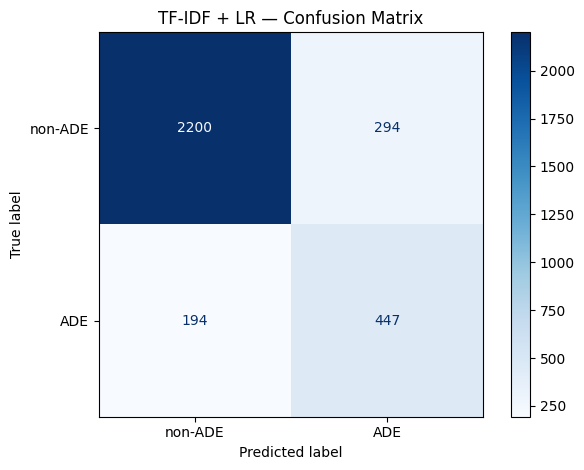

In [18]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        token_pattern=r'\S+',
        sublinear_tf=True,
        max_features=100_000,
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # handles 80/20 imbalance
        random_state=RANDOM_SEED,
        solver='lbfgs',
    )),
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C':             [0.1, 1.0, 10.0],
}

grid_search = GridSearchCV(
    lr_pipeline, param_grid, cv=5,
    scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_tok_train, y_train)
y_pred_lr = grid_search.predict(X_tok_test)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV F1 (ADE): {grid_search.best_score_:.4f}\n')
print('=== Model 2: TF-IDF + Logistic Regression ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=['non-ADE', 'ADE']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['non-ADE','ADE']).plot(cmap='Blues')
plt.title('TF-IDF + LR — Confusion Matrix')
plt.tight_layout(); plt.savefig('cm_lr.png', dpi=150); plt.show()


## 8 — BiLSTM + BioWordVec + Query Attention

Architecture inspired by **Ramamoorthy & Murugan (2018)**
*“An Attentive Sequence Model for ADE Extraction from Biomedical Text”*

| Aspect | Paper | Our implementation |
|---|---|---|
| Task | Token-level NER + relation extraction | Sentence-level binary classification |
| Embeddings | PubMed Word2Vec (trained on large corpus) | **BioWordVec** (fastText, PubMed + MIMIC-III) |
| Encoder | BiLSTM hidden=150, 2 layers | Same |
| Attention | Multiplicative intra-sequence | **Query attention** (better for sentence classification) |
| Optimiser | Adagrad lr=0.001, batch=16 | **Adam lr=3e-4, batch=64, ReduceLROnPlateau** |
| Paper result | ADE F1=86.78 (token-level) | — |

### 8.1 Load BioWordVec embeddings

In [22]:
from gensim.models import KeyedVectors
import os, gc

BIO_VEC_PATH = 'BioWordVec_PubMed_MIMICIII_d200.vec.bin'

if not os.path.exists(BIO_VEC_PATH):
    drive_path = f'/content/drive/MyDrive/{BIO_VEC_PATH}'
    if os.path.exists(drive_path):
        BIO_VEC_PATH = drive_path
    else:
        print('Downloading BioWordVec (~13 GB, 3-5 min on Colab)...')
        os.system('wget -q --show-progress '
                  'https://ftp.ncbi.nlm.nih.gov/pub/lu/Suppl/BioSentVec/'
                  'BioWordVec_PubMed_MIMICIII_d200.vec.bin')

print('Loading top 500K vectors (~400 MB RAM)...')

Loading top 500K vectors (~400 MB RAM)...


### 8.2 Vocabulary & embedding matrix

In [23]:

bio_wv    = KeyedVectors.load_word2vec_format(
                BIO_VEC_PATH, binary=True, limit=500_000)
EMBED_DIM = bio_wv.vector_size   # 200
print(f'Loaded {len(bio_wv):,} vectors | dim={EMBED_DIM}')

# Vocab
MAX_LEN = 100   # covers >99% of sentences

def build_vocab(texts, min_freq=2):
    counter = Counter()
    for t in texts: counter.update(shared_tokenize(t))
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for token, freq in counter.most_common():
        if freq >= min_freq: vocab[token] = len(vocab)
    return vocab

def encode(text, vocab, max_len=MAX_LEN):
    tokens = shared_tokenize(text)[:max_len]
    ids    = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    length = max(len(ids), 1)
    ids   += [vocab['<PAD>']] * (max_len - length)
    return ids, length

vocab      = build_vocab(X_raw_train, min_freq=2)
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE:,} tokens')


embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
found = 0
for token, idx in vocab.items():
    if token in bio_wv:
        embedding_matrix[idx] = bio_wv[token]
        found += 1
    else:
        embedding_matrix[idx] = np.random.uniform(-0.01, 0.01, EMBED_DIM)
embedding_matrix[vocab['<PAD>']] = np.zeros(EMBED_DIM)

print(f'Coverage: {found}/{VOCAB_SIZE} ({found/VOCAB_SIZE*100:.1f}%)')
del bio_wv; gc.collect()  # free 400MB once matrix is built

Loaded 500,000 vectors | dim=200
Vocabulary size: 12,680 tokens
Coverage: 9695/12680 (76.5%)


36299

### 8.3 Model architecture

In [24]:
class ADEDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.ids=[]; self.lengths=[]; self.labels=labels
        for t in texts:
            ids, length = encode(t, vocab)
            self.ids.append(ids); self.lengths.append(length)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return (torch.tensor(self.ids[i],     dtype=torch.long),
                torch.tensor(self.lengths[i], dtype=torch.long),
                torch.tensor(self.labels[i],  dtype=torch.long))

BATCH_SIZE = 64
train_ds = ADEDataset(X_raw_train, y_train, vocab)
val_ds   = ADEDataset(X_raw_val,   y_val,   vocab)
test_ds  = ADEDataset(X_raw_test,  y_test,  vocab)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [31]:
class QueryAttention(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.W = nn.Linear(h, h)
        self.v = nn.Linear(h, 1, bias=False)

    def forward(self, H, pad_mask=None):
        s = self.v(torch.tanh(self.W(H))).squeeze(-1)
        if pad_mask is not None:
            pad_mask = pad_mask[:, :s.size(1)]   # ← fix lives here
            s = s.masked_fill(pad_mask, float('-inf'))
        w = torch.nan_to_num(F.softmax(s, dim=-1), nan=0.0)
        return (w.unsqueeze(-1) * H).sum(1), w


class BiLSTMAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout_p, emb_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if emb_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(emb_matrix, dtype=torch.float32))
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, bidirectional=True,
                              dropout=dropout_p if num_layers > 1 else 0.0)
        self.attention = QueryAttention(hidden_dim * 2)
        self.dropout   = nn.Dropout(dropout_p)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        emb    = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        H, _   = pad_packed_sequence(self.bilstm(packed)[0], batch_first=True)
        pad_mask = (x == 0)   # QueryAttention trims this internally
        ctx, _  = self.attention(self.dropout(H), pad_mask=pad_mask)
        return self.fc(ctx)


# Instantiate fresh model
model_bilstm = BiLSTMAttentionClassifier(
    VOCAB_SIZE, EMBED_DIM, hidden_dim=150, num_layers=2,
    num_classes=2, dropout_p=0.4, emb_matrix=embedding_matrix).to(DEVICE)

counts_train = np.bincount(y_train)
wts  = torch.tensor(1.0 / counts_train, dtype=torch.float32).to(DEVICE)
wts  = wts / wts.sum() * 2
crit = nn.CrossEntropyLoss(weight=wts)
optim_bilstm = torch.optim.Adam(model_bilstm.parameters(), lr=3e-4, weight_decay=1e-4)
sched        = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_bilstm, mode='max', factor=0.5, patience=2)

print(f'Model ready — {sum(p.numel() for p in model_bilstm.parameters() if p.requires_grad):,} parameters')

Model ready — 3,592,002 parameters


### 8.4 Training

In [32]:
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, lengths, y in loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)
            if train: optimizer.zero_grad()
            logits = model(x, lengths)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            preds.extend(logits.argmax(-1).cpu().numpy())
            labels.extend(y.cpu().numpy())
    f1 = f1_score(labels, preds, pos_label=1, zero_division=0)
    return total_loss / len(loader), f1, np.array(preds)

NUM_EPOCHS, PATIENCE = 30, 5
best_val_f1, patience_ctr, best_state = 0.0, 0, None
history = {'train_loss':[], 'train_f1':[], 'val_loss':[], 'val_f1':[]}

print(f'{"Ep":>3} │ {"TrLoss":>7} │ {"TrF1":>6} │ {"VlLoss":>7} │ {"VlF1":>6}')
print('─' * 42)

for ep in range(1, NUM_EPOCHS + 1):
    trl, trf, _ = run_epoch(model_bilstm, train_loader, optim_bilstm, crit, DEVICE, True)   # ← fixed
    vll, vlf, _ = run_epoch(model_bilstm, val_loader,   optim_bilstm, crit, DEVICE, False)  # ← fixed
    sched.step(vlf)
    history['train_loss'].append(trl); history['train_f1'].append(trf)
    history['val_loss'].append(vll);   history['val_f1'].append(vlf)
    flag = ' ◀' if vlf > best_val_f1 else ''
    print(f'{ep:>3} │ {trl:>7.4f} │ {trf:>6.4f} │ {vll:>7.4f} │ {vlf:>6.4f}{flag}')
    if vlf > best_val_f1:
        best_val_f1, patience_ctr = vlf, 0
        best_state = {k: v.clone() for k, v in model_bilstm.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stop at epoch {ep}  (best val F1={best_val_f1:.4f})')
            break

model_bilstm.load_state_dict(best_state)
print(f'Best validation F1: {best_val_f1:.4f}')

 Ep │  TrLoss │   TrF1 │  VlLoss │   VlF1
──────────────────────────────────────────
  1 │  0.5518 │ 0.5095 │  0.4840 │ 0.5616 ◀
  2 │  0.4517 │ 0.6013 │  0.4466 │ 0.6164 ◀
  3 │  0.4148 │ 0.6281 │  0.4268 │ 0.6416 ◀
  4 │  0.3729 │ 0.6723 │  0.4111 │ 0.6609 ◀
  5 │  0.3458 │ 0.6885 │  0.3991 │ 0.6382
  6 │  0.3067 │ 0.7265 │  0.4021 │ 0.6870 ◀
  7 │  0.2841 │ 0.7526 │  0.4199 │ 0.7057 ◀
  8 │  0.2418 │ 0.7789 │  0.4223 │ 0.7031
  9 │  0.2270 │ 0.8004 │  0.4387 │ 0.7150 ◀
 10 │  0.2037 │ 0.8265 │  0.3940 │ 0.6914
 11 │  0.1785 │ 0.8425 │  0.4645 │ 0.7207 ◀
 12 │  0.1684 │ 0.8543 │  0.4932 │ 0.7283 ◀
 13 │  0.1468 │ 0.8724 │  0.6346 │ 0.7281
 14 │  0.1309 │ 0.8852 │  0.8158 │ 0.7130
 15 │  0.1207 │ 0.9019 │  0.6290 │ 0.7251
 16 │  0.0923 │ 0.9221 │  0.6548 │ 0.7348 ◀
 17 │  0.0950 │ 0.9241 │  0.7486 │ 0.7153
 18 │  0.0901 │ 0.9259 │  0.6881 │ 0.7415 ◀
 19 │  0.0850 │ 0.9279 │  0.5522 │ 0.7223
 20 │  0.0761 │ 0.9380 │  0.7387 │ 0.7234
 21 │  0.0749 │ 0.9377 │  0.8549 │ 0.7220
 22 │  0.06

### 8.5 Evaluation

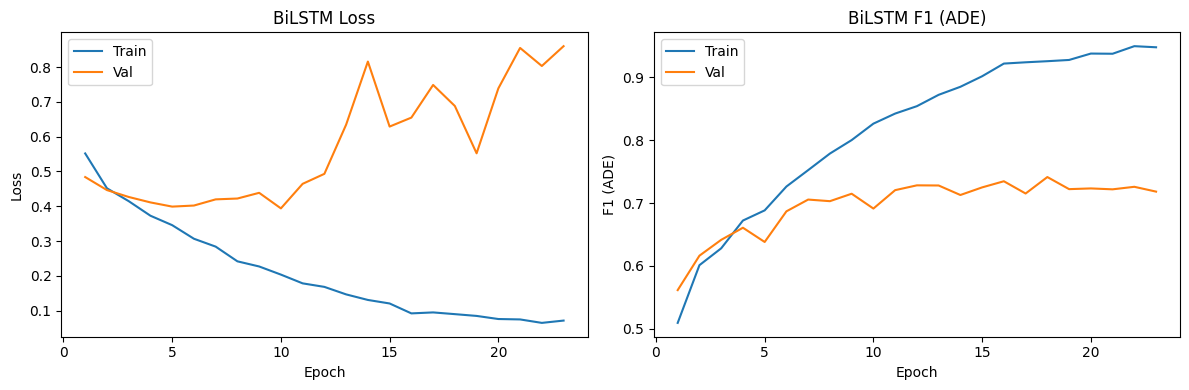


=== Model 3: BiLSTM + BioWordVec + Attention ===
              precision    recall  f1-score   support

     non-ADE       0.93      0.92      0.93      2494
         ADE       0.70      0.74      0.72       641

    accuracy                           0.88      3135
   macro avg       0.82      0.83      0.82      3135
weighted avg       0.89      0.88      0.88      3135



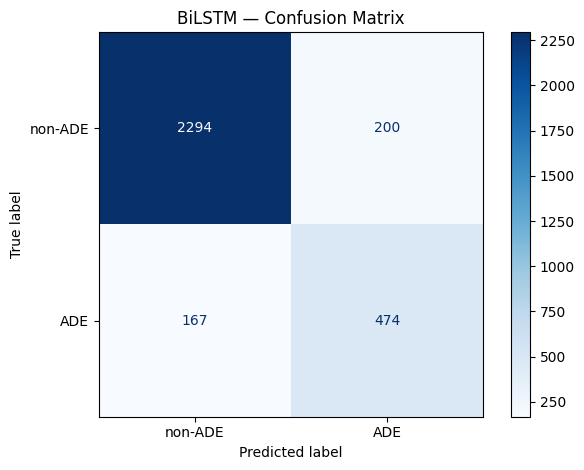

In [33]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_ran, history['train_loss'], label='Train')
ax1.plot(epochs_ran, history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('BiLSTM Loss')
ax1.legend()
ax2.plot(epochs_ran, history['train_f1'], label='Train')
ax2.plot(epochs_ran, history['val_f1'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 (ADE)'); ax2.set_title('BiLSTM F1 (ADE)')
ax2.legend()
plt.tight_layout(); plt.savefig('bilstm_curves.png', dpi=150); plt.show()

_, _, y_pred_bilstm = run_epoch(model_bilstm, test_loader, optim, crit, DEVICE, False)
print('\n=== Model 3: BiLSTM + BioWordVec + Attention ===')
print(classification_report(y_test, y_pred_bilstm, target_names=['non-ADE','ADE']))

cm = confusion_matrix(y_test, y_pred_bilstm)
ConfusionMatrixDisplay(cm, display_labels=['non-ADE','ADE']).plot(cmap='Blues')
plt.title('BiLSTM — Confusion Matrix'); plt.tight_layout()

## 9 — PubMedBERT Fine-tuning

**Reference: Dong et al. (2024)** — *“BERT-based LM for accurate drug adverse event
extraction from social media”* — Frontiers in Public Health 12:1392180

| | Dong et al. (2024) | Our model |
|---|---|---|
| Model | BERT-base-uncased (general domain) | **PubMedBERT** (biomedical-specific) |
| Task | Token-level NER (B-AE / I-AE / O) | Sentence-level binary classification |
| Split | 80/20 random, 10 repetitions, no dedup | 70/15/15 stratified, with dedup |
| Epochs | 50 (NER head trains nearly from scratch) | 3–5 (classification head fine-tuning) |
| Batch | 32 (V100 32GB) | 16 (T4 16GB) |
| LR | 1e-5 | 2e-5 |
| Best result | F1(B-AE)=0.8575 F1(I-AE)=0.9049 | — |

Direct numerical comparison is **not valid** (different tasks), but the gap between
their general BERT and our domain-specific PubMedBERT qualitatively shows the value
of biomedical pretraining.

### 9.1 Tokenization & HuggingFace datasets

In [ ]:
BERT_MODEL = 'microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract'
bert_tok   = AutoTokenizer.from_pretrained(BERT_MODEL)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)

def tokenize_bert(examples):
    return bert_tok(examples['text'], truncation=True,
                    padding='max_length', max_length=128)

def to_hf(texts, labels):
    ds = HFDataset.from_dict({'text': texts, 'label': labels.tolist()})
    return ds.map(tokenize_bert, batched=True)

train_hf = to_hf(X_raw_train, y_train)
val_hf   = to_hf(X_raw_val,   y_val)
test_hf  = to_hf(X_raw_test,  y_test)

def compute_metrics(ep):
    preds = np.argmax(ep.predictions, axis=-1)
    return {
        'f1_ade':   f1_score(ep.label_ids, preds, pos_label=1, zero_division=0),
        'macro_f1': f1_score(ep.label_ids, preds, average='macro', zero_division=0),
        'accuracy': accuracy_score(ep.label_ids, preds),
    }

### 9.2 Trainer configuration

In [ ]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        wts = torch.tensor([1.0/counts_train[0], 1.0/counts_train[1]],
                           dtype=torch.float32).to(outputs.logits.device)
        wts /= wts.sum() / 2
        loss = nn.CrossEntropyLoss(weight=wts)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

bert_args = TrainingArguments(
    output_dir='./bert_out',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_ade',
    greater_is_better=True,
    logging_steps=50,
    seed=RANDOM_SEED,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
)

trainer = WeightedTrainer(
    model=bert_model, args=bert_args,
    train_dataset=train_hf, eval_dataset=val_hf,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

### 9.3 Training

In [ ]:
print('Fine-tuning PubMedBERT  (~20 min on T4 GPU)...')
trainer.train()

### 9.4 Evaluation


=== Model 4: PubMedBERT fine-tuned ===
              precision    recall  f1-score   support

     non-ADE       0.98      0.96      0.97      2494
         ADE       0.87      0.92      0.89       641

    accuracy                           0.96      3135
   macro avg       0.92      0.94      0.93      3135
weighted avg       0.96      0.96      0.96      3135



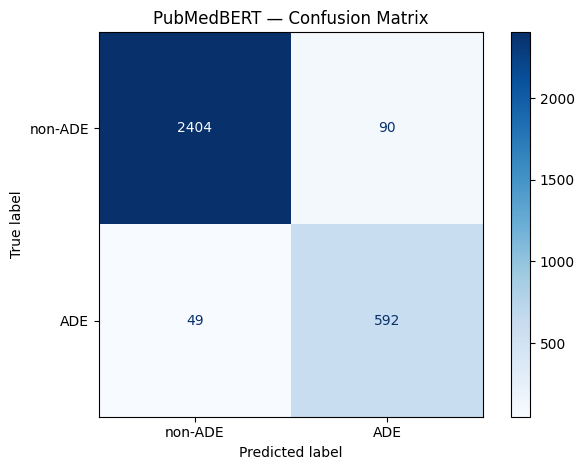

In [36]:
bert_out      = trainer.predict(test_hf)
y_pred_bert   = np.argmax(bert_out.predictions, axis=-1)

print('\n=== Model 4: PubMedBERT fine-tuned ===')
print(classification_report(y_test, y_pred_bert, target_names=['non-ADE','ADE']))

cm = confusion_matrix(y_test, y_pred_bert)
ConfusionMatrixDisplay(cm, display_labels=['non-ADE','ADE']).plot(cmap='Blues')
plt.title('PubMedBERT — Confusion Matrix')
plt.tight_layout()
plt.show()

## 10 — GPT Few-shot Classification

Course topic: **Session 9.7 — Prompt Engineering**

Technique used: **8-shot prompting** (4 ADE + 4 non-ADE examples in context)

Key contrast with PubMedBERT:
- PubMedBERT = **fine-tuned specialist** (trained on ADE data)
- GPT = **general LLM via prompting** (no training, no labelled data needed)

### 10.1 Prompt design & few-shot examples

In [ ]:
import json

FULL_TEST       = True
CHECKPOINT_FILE = 'gpt_predictions.json'

try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_NLP_API_KEY')
    print('API key loaded from Colab secrets.')
except Exception:
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')

OPENAI_MODEL = 'gpt-4o-mini'
client       = OpenAI(api_key=OPENAI_API_KEY)

# 8-shot examples: 4 ADE + 4 non-ADE, hand-picked from training set
FEW_SHOT = [
    ('A 14-year-old girl with newly diagnosed SLE developed a pruritic bullous eruption while on prednisone.', 1),
    ('Diffuse proliferative glomerulonephritis after bone marrow transplantation.', 0),
    ('Allergic and irritant contact dermatitis to calcipotriol.', 1),
    ('Mianserin 30 mg/day, etizolam 1 mg/day and flunitrazepam 1 mg/day were administered.', 0),
    ('Heparin-induced thrombocytopenia is a rare and serious complication of anticoagulation therapy.', 1),
    ('Blood pressure was monitored every 6 hours during the treatment period.', 0),
    ('An emergency tracheostomy was life saving.', 0),
    ('This represents the first reported case of syphilitic meningitis in a lupus patient.', 0),
]

def build_prompt(sentence):
    msgs = [{'role': 'system', 'content': (
        'You are a biomedical NLP classifier. '
        'Classify whether a sentence from a medical case report describes '
        'an Adverse Drug Event (ADE) — an unintended harmful reaction '
        'directly caused by a drug. '
        'A sentence is NOT an ADE if it only describes: '
        'drug administration, dosage, monitoring, lack of efficacy, '
        'or pre-existing conditions unrelated to drug intake. '
        'Only reply with 1 (ADE present) or 0 (no ADE). '
        'Be conservative — only label 1 if the adverse reaction is explicit.'
    )}]
    for text, label in FEW_SHOT:
        msgs.append({'role': 'user',      'content': text})
        msgs.append({'role': 'assistant', 'content': str(label)})
    msgs.append({'role': 'user', 'content': sentence})
    return msgs

def predict_gpt(text, retries=3):
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=build_prompt(text),
            )
            return 1 if '1' in resp.choices[0].message.content.strip() else 0
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f'Error: {e}')
                return 0

### 10.2 Inference (with checkpointing)

In [ ]:
gpt_texts  = X_raw_test
gpt_labels = y_test

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        checkpoint = json.load(f)
    y_pred_gpt = checkpoint['preds']
    start_idx  = len(y_pred_gpt)
    print(f'Resuming from checkpoint — {start_idx}/{len(gpt_texts)} already done')
else:
    y_pred_gpt = []
    start_idx  = 0
    print(f'Starting fresh — {len(gpt_texts)} sentences to classify')

print(f'Running {OPENAI_MODEL} on {len(gpt_texts) - start_idx} remaining sentences...')

for i, text in enumerate(tqdm(gpt_texts[start_idx:],
                               initial=start_idx,
                               total=len(gpt_texts),
                               desc='GPT')):
    y_pred_gpt.append(predict_gpt(text))

    if (start_idx + i + 1) % 50 == 0:
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'preds': y_pred_gpt}, f)

with open(CHECKPOINT_FILE, 'w') as f:
    json.dump({'preds': y_pred_gpt}, f)

y_pred_gpt = np.array(y_pred_gpt)

### 10.3 Evaluation

In [ ]:
print(f'=== Model 5: GPT few-shot (n={len(gpt_labels)}) ===')
print(classification_report(gpt_labels, y_pred_gpt, target_names=['non-ADE', 'ADE']))

cm = confusion_matrix(gpt_labels, y_pred_gpt)
ConfusionMatrixDisplay(cm, display_labels=['non-ADE', 'ADE']).plot(cmap='Blues')
plt.title('GPT few-shot — Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_gpt.png', dpi=150)
plt.show()

## 11 — Final Comparison

### 11.1 Results table

In [48]:
def row(name, y_true, y_pred):
    return {
        'Model':           name,
        'Accuracy':        round(accuracy_score(y_true, y_pred), 4),
        'Precision (ADE)': round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (ADE)':    round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'F1 (ADE)':        round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Macro F1':        round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }

results = pd.DataFrame([
    row('Majority Baseline',               y_test,    y_pred_dummy),
    row('TF-IDF + Naïve Bayes',            y_test,    y_pred_nb),
    row('TF-IDF + Logistic Regression',    y_test,    y_pred_lr),
    row('BiLSTM + BioWordVec + Attention', y_test,    y_pred_bilstm),
    row('PubMedBERT (fine-tuned)',         y_test,    y_pred_bert),
    row(f'GPT few-shot (n={len(gpt_labels)})', gpt_labels, y_pred_gpt),
])

display(results.style.format(precision=4))


,Model,Accuracy,Precision (ADE),Recall (ADE),F1 (ADE),Macro F1
0,Majority Baseline,0.7955,0.0000,0.0000,0.0000,0.4431
1,TF-IDF + Naïve Bayes,0.8533,0.7388,0.4368,0.5490,0.7307
2,TF-IDF + Logistic Regression,0.8443,0.6032,0.6973,0.6469,0.7735
3,BiLSTM + BioWordVec + Attention,0.8829,0.7033,0.7395,0.7209,0.8234
4,PubMedBERT (fine-tuned),0.9557,0.8680,0.9236,0.8949,0.9334
5,GPT few-shot (n=300),0.8500,0.5784,0.9672,0.7239,0.8105


### 11.2 Comparative chart

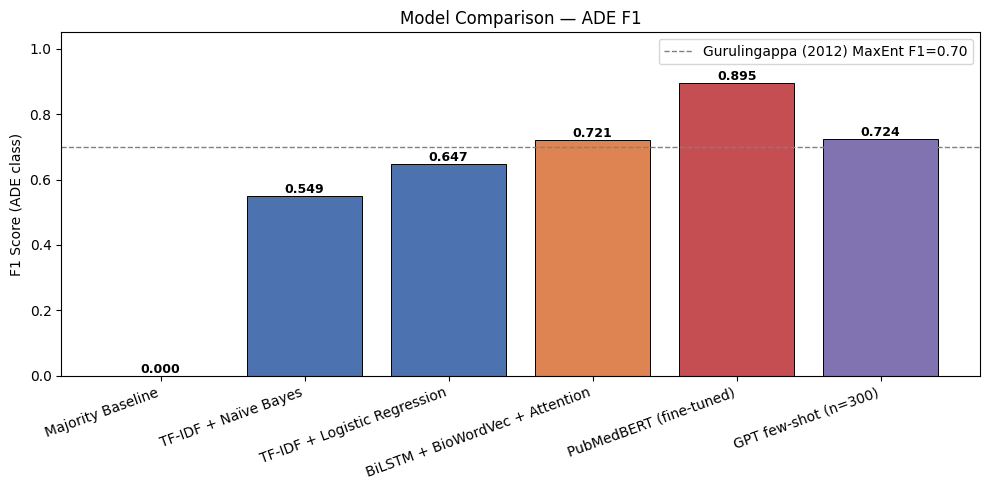

In [50]:
# Bar chart — F1 (ADE class)
fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#888888','#4C72B0','#4C72B0','#DD8452','#C44E52','#8172B2']
bars = ax.bar(results['Model'], results['F1 (ADE)'],
              color=colours, edgecolor='black', linewidth=0.7)
ax.axhline(0.70, linestyle='--', color='gray', linewidth=1,
           label='Gurulingappa (2012) MaxEnt F1=0.70')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score (ADE class)')
ax.set_title('Model Comparison — ADE F1')
ax.set_xticklabels(results['Model'], rotation=20, ha='right')
for bar, val in zip(bars, results['F1 (ADE)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()